# Week 16 — Supersonic Shape Optimization with Verified CFD
**FlowMLLab · Ehsan Roohi · MIE 690A**

[Open in Colab](https://colab.research.google.com/github/Ehsan-Roohi/FlowMLLab/blob/main/notebooks/week16/W16_Supersonic_Shape_Optimization.ipynb)

This complete worked lab uses newly generated Gmsh/SU2 data. You will inspect numerical verification, compare learned models, propose a fixed-volume shape, and examine fresh CFD checks.

**Claim boundary:** the computed target is near-field peak pressure at $r/L=0.5$. This notebook does not compute atmospheric propagation or PLdB, and its axisymmetric body is not TMS-10. Read `ASSIGNMENT.md` for assessed extensions.

Run from a clone of FlowMLLab. Dependencies for the data-based lab: numpy, scipy, scikit-learn, pandas, matplotlib. Gmsh and SU2 are required only for regenerating CFD.

In [1]:
# FLOWMLLAB_COLAB_BOOTSTRAP_V1: sparse checkout for Week 16
from pathlib import Path
import sys, json, hashlib, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p/'qa/week16/learning.py').exists()), None)
if ROOT is None:
    import importlib.util, subprocess
    if importlib.util.find_spec('google.colab') is not None:
        target=Path('/content/FlowMLLab_week16')
        if not target.exists():
            subprocess.run(['git','clone','--depth','1','--filter=blob:none','--sparse','https://github.com/Ehsan-Roohi/FlowMLLab.git',str(target)],check=True)
            subprocess.run(['git','-C',str(target),'sparse-checkout','set','qa/week16','results/week16_lowboom','notebooks/week16'],check=True)
        ROOT=target
    else:
        raise RuntimeError('Clone FlowMLLab, then open this notebook inside the checkout.')
sys.path.insert(0, str(ROOT/'qa/week16'))
from cfd import radius, VOLUME
from learning import Surrogate, optimize
E = ROOT/'results/week16_lowboom'
data = np.load(E/'dataset.npz')
summary = json.loads((E/'summary.json').read_text())
assert hashlib.sha256((E/'dataset.npz').read_bytes()).hexdigest() == summary['dataset_sha256']
print('Dataset verified:', summary['dataset_sha256'])
print('CFD cases:', len(data['parameters']))
display(pd.Series(json.loads((E/'software_versions.json').read_text()), name='Recorded generation environment'))

Dataset verified: 8148f318598ce3e48ca27cbcd39e7ad5cfd8d98a2bfe75d00e286aa79e662a2f
CFD cases: 44


numpy                                                       2.3.5
scipy                                                      1.17.0
scikit-learn                                                1.8.0
gmsh                                                       4.15.2
matplotlib                                                 3.10.8
nbformat                                                   5.11.1
nbclient                                                   0.11.0
meshio                                                      5.3.5
python          3.12.14 (main, Aug 25 2026, 14:00:49) [Clang 2...
SU2                             8.5.0 official linux64-omp binary
su2_sha256      0b8b343f41a4c441ab9900a597de6d3b56eca688157e3f...
Name: Recorded generation environment, dtype: object

## 1. Geometry and volume
For $s=x/L$, define $f(s)=\sin(\pi s)\exp[a(2s-1)+b\cos(2\pi s)]$ and $r(s)=c f(s)$.
The constraint gives $c=\sqrt{V/(\pi L\int_0^1 f(s)^2\,ds)}$.

These are three-dimensional bodies of revolution. The two-dimensional mesh is a meridional representation of the axisymmetric equations, including their radial source terms.

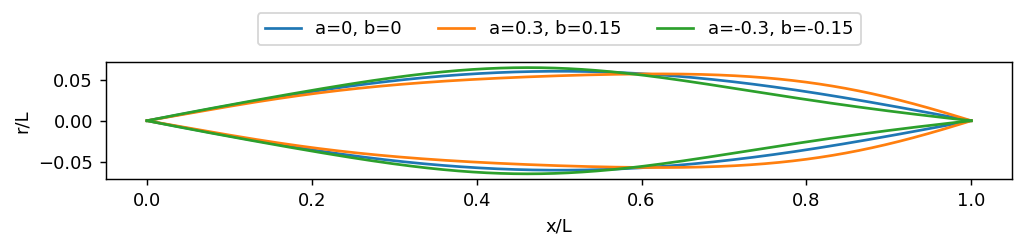

,a,b,volume,relative_error
0,0.0,0.00,0.005655,0.000000e+00
1,0.3,0.15,0.005655,2.209344e-14
2,-0.3,-0.15,0.005655,9.214851e-15


In [2]:
x = np.linspace(0,1,2001)
fig,ax = plt.subplots(figsize=(9,2.5))
checks=[]
for a,b in [(0,0),(.3,.15),(-.3,-.15)]:
    r=radius(x,a,b)
    line,=ax.plot(x,r,label=f'a={a}, b={b}')
    ax.plot(x,-r,color=line.get_color())
    volume=np.pi*np.trapezoid(r*r,x)
    checks.append({'a':a,'b':b,'volume':volume,'relative_error':abs(volume/VOLUME-1)})
ax.set(xlabel='x/L',ylabel='r/L',aspect='equal');ax.legend(ncol=3,loc='upper center',bbox_to_anchor=(.5,1.5));plt.show()
display(pd.DataFrame(checks))
assert max(r['relative_error'] for r in checks)<1e-5

## 2. Accepting the CFD data
Pressure is reconstructed as $p=(\gamma-1)[\rho E-(\rho u)^2/(2\rho)-(\rho v)^2/(2\rho)]$.
The pressure coefficient is $C_p=(p-p_\infty)/(\tfrac12\gamma p_\infty M^2)$.

We separately check an independent cone solution, discrete convergence, mesh sensitivity and domain sensitivity. The cone benchmark is not a complete sonic-boom validation.

exact             {'shock_angle_deg': 34.03574212191822, 'pressu...
cfd_cp_mean                                                0.061387
relative_error                                             0.009957
wall_seconds                                              15.841388
passed                                                         True
dtype: object

baseline_peak_mesh_difference      0.024569
baseline_drag_mesh_difference      0.018995
baseline_wave_mesh_difference      0.038572
baseline_domain_peak_difference    0.001425
optimized_peak_mesh_difference     0.033157
optimized_drag_mesh_difference     0.026601
peak_reduction_fine                0.215391
peak_reduction_finer               0.208422
drag_change_fine                  -0.052827
drag_change_finer                 -0.045426
dtype: float64

,name,cells,iterations,residual_drop,drag_tail_relative_range
0,train_000,45408,501,12.858581,0.0
1,train_001,45408,501,12.936662,0.0
2,train_002,45408,501,12.864711,0.0
3,train_003,45408,501,12.973364,0.0
4,train_004,45408,501,12.932987,0.0
5,train_005,45408,501,12.938049,0.0
6,train_006,45408,501,12.935266,0.0
7,train_007,45408,501,12.939382,0.0


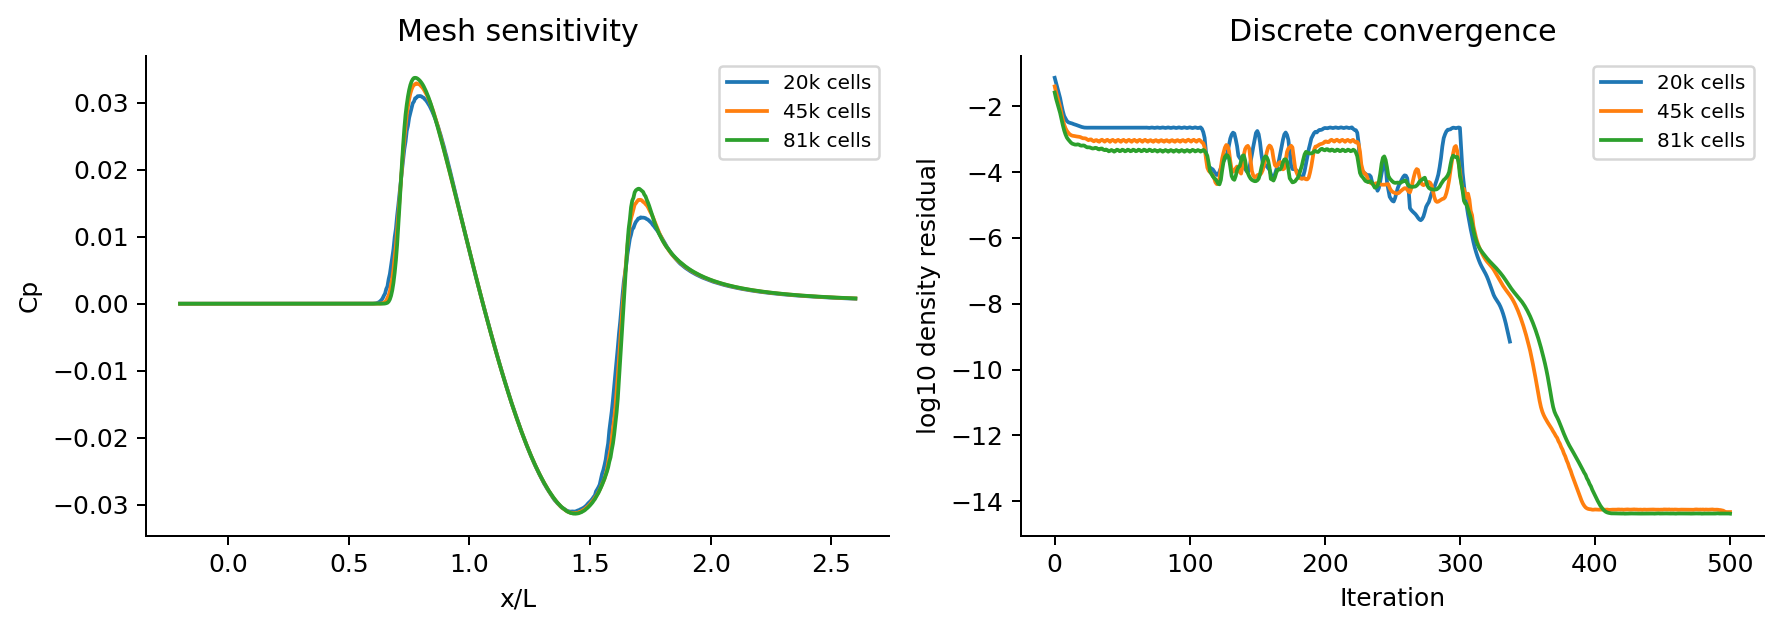

In [3]:
display(pd.Series(summary['benchmark']))
display(pd.Series(summary['validation']))
cases = pd.read_csv(E/'case_metrics.csv')
assert len(cases)==44 and cases['converged'].all()
display(cases[['name','cells','iterations','residual_drop','drag_tail_relative_range']].head(8))
display(Image(filename=str(E/'numerical_verification.png')))

## 3. Frozen geometry split
POD and scalers are fitted on training cases only. Validation selects the design model. The test cases remain outside fitting and selection. Extrapolation extends parameter $b$ beyond the training interval. All splits belong to the same two-parameter geometry family.

train            24
test              8
validation        6
extrapolation     6
Name: Cases, dtype: int64

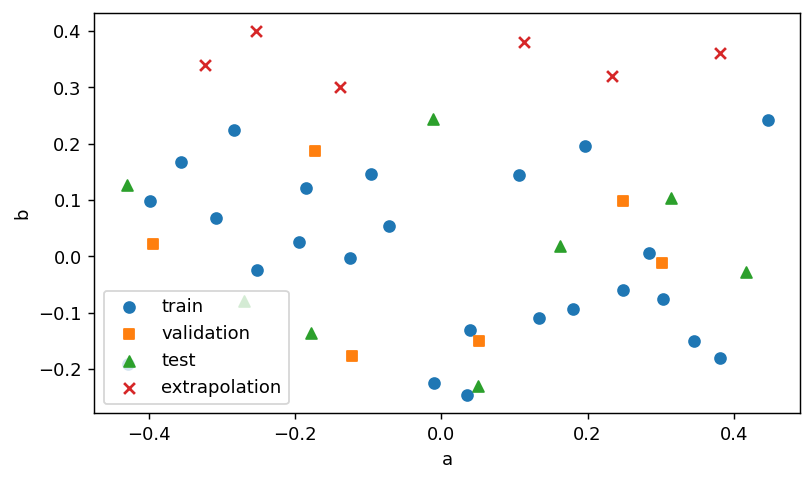

In [4]:
display(pd.Series(data['splits']).value_counts().rename('Cases'))
fig,ax=plt.subplots(figsize=(7,4))
for split,marker in [('train','o'),('validation','s'),('test','^'),('extrapolation','x')]:
    mask=data['splits']==split
    ax.scatter(*data['parameters'][mask].T,label=split,marker=marker)
ax.set(xlabel='a',ylabel='b');ax.legend();plt.show()
assert len(set(data['names']))==44
assert len(np.unique(data['parameters'],axis=0))==44

## 4. Compare ridge, a neural network and a Gaussian process
The POD expansion is $C_p(x;\theta)\approx\overline C_p(x)+\sum_{k=1}^{K}z_k(\theta)\phi_k(x)$.
Each model predicts the same modal coefficients and log pressure drag. This notebook reruns model fitting, not the expensive CFD campaign.

The MLP has two 32-neuron tanh hidden layers and a fixed seed. This is a teaching comparison, not a statistical architecture ranking. Record any optimizer warnings rather than suppressing them.

In [5]:
train=data['splits']=='train'
models={};scores=[]
for kind in ['ridge','mlp','gp']:
    model=Surrogate(kind).fit(data['parameters'][train],data['waveforms'][train],data['cd'][train])
    models[kind]=model
    for split in ['validation','test','extrapolation']:
        mask=data['splits']==split
        w,cd=model.predict(data['parameters'][mask]);truth=data['waveforms'][mask]
        scores.append(dict(model=kind,split=split,
            waveform_error=np.linalg.norm(w-truth)/np.linalg.norm(truth),
            peak_error=np.mean(abs(w.max(axis=1)/truth.max(axis=1)-1)),
            drag_error=np.mean(abs(cd/data['cd'][mask]-1))))
    print(kind,'training seconds:',round(model.seconds,3),'warnings:',model.fit_warnings)
scores=pd.DataFrame(scores)
display(scores)
val=scores[scores.split=='validation'].copy()
selected=val.loc[(val.peak_error+val.drag_error).idxmin(),'model']
print('Validation-selected model:',selected)

ridge training seconds: 0.001 warnings: []
mlp training seconds: 0.113 warnings: []
gp training seconds: 0.053 warnings: []
Validation-selected model: mlp


,model,split,waveform_error,peak_error,drag_error
0,ridge,validation,0.086612,0.050343,0.053943
1,ridge,test,0.112687,0.068461,0.079948
2,ridge,extrapolation,0.354101,0.030591,0.404263
3,mlp,validation,0.040911,0.013475,0.016313
4,mlp,test,0.051374,0.022721,0.024773
5,mlp,extrapolation,0.314252,0.060220,0.212882
6,gp,validation,0.044546,0.019795,0.017194
7,gp,test,0.087966,0.028644,0.019915
8,gp,extrapolation,0.702843,0.263143,0.137421


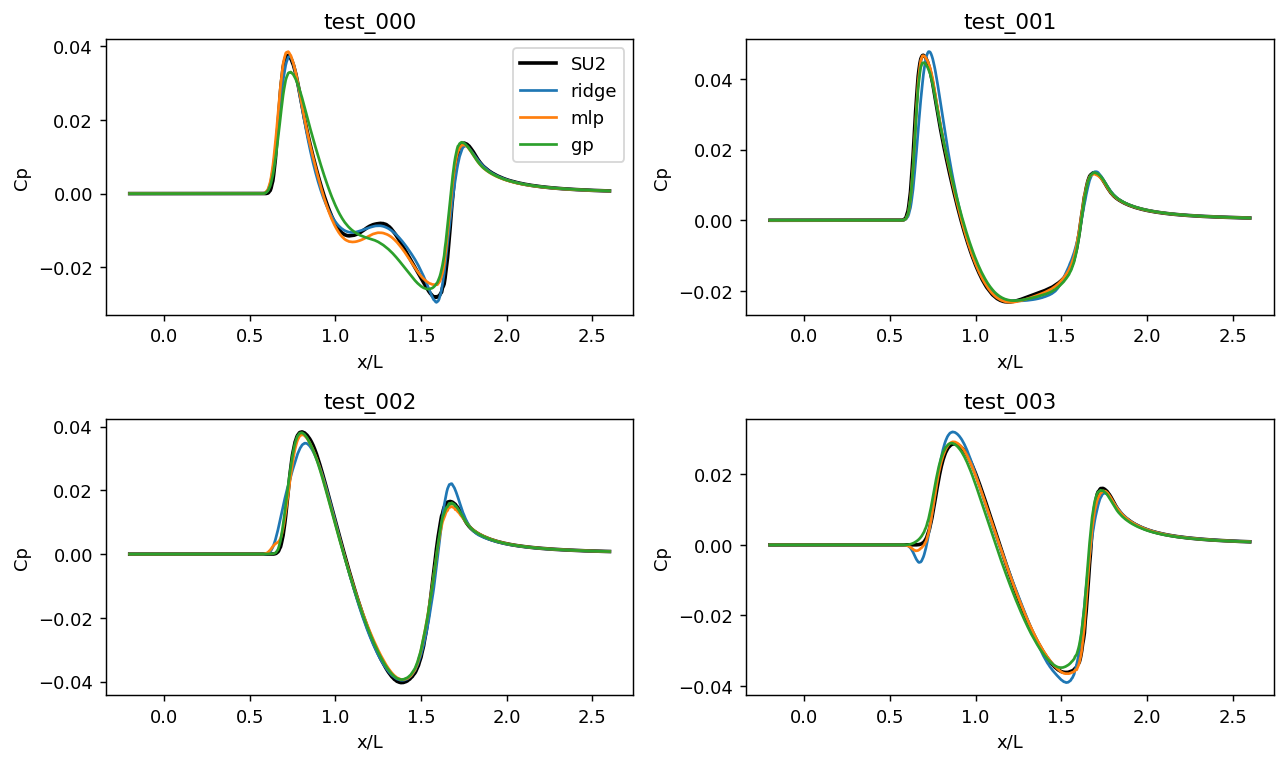

In [6]:
test=np.where(data['splits']=='test')[0]
fig,axs=plt.subplots(2,2,figsize=(10,6))
for ax,i in zip(axs.flat,test[:4]):
    ax.plot(data['x'],data['waveforms'][i],'k',lw=2,label='SU2')
    for kind,model in models.items():
        w,_=model.predict(data['parameters'][i]);ax.plot(data['x'],w[0],label=kind)
    ax.set(title=str(data['names'][i]),xlabel='x/L',ylabel='Cp')
axs[0,0].legend();fig.tight_layout();plt.show()

## 5. Propose a design with the surrogate
The objective is minimum peak $C_p$ at $r/L=0.5$, with pressure drag at most 2% above baseline. Volume is enforced by parameterization. The retained optimization code uses a conservative search margin and checks feasibility explicitly after CFD. A predicted optimum is only a candidate.

Inspect the search implementation in `qa/week16/learning.py`; then compare the actual proposals below. The retained candidate is not replaced by a new unverified design during notebook execution.

Reproduced surrogate optimum: {'name': 'optimized', 'a': 0.3295311728342745, 'b': 0.10766674629294916, 'predicted_peak_cp': 0.025892091261320426, 'predicted_cd': 0.001318467244300271}
minimize max Cp at r/L=0.5, pressure drag <= 1.02 baseline
Surrogate evaluations: 1005


,name,a,b,predicted_peak_cp,predicted_cd
0,optimized,0.324953,0.122378,0.026102,0.001318
1,alternative_1,0.319600,0.240472,0.027836,0.001330
2,alternative_2,0.286478,0.021652,0.027868,0.001337


,name,a,b,predicted_peak_cp,actual_peak_cp,predicted_cd,actual_cd,peak_reduction,constraint_pass
0,optimized,0.324953,0.122378,0.026102,0.025789,0.001318,0.001249,0.215391,True
1,alternative_1,0.319600,0.240472,0.027836,0.026967,0.001330,0.001355,0.179544,False
2,alternative_2,0.286478,0.021652,0.027868,0.027760,0.001337,0.001330,0.155417,True


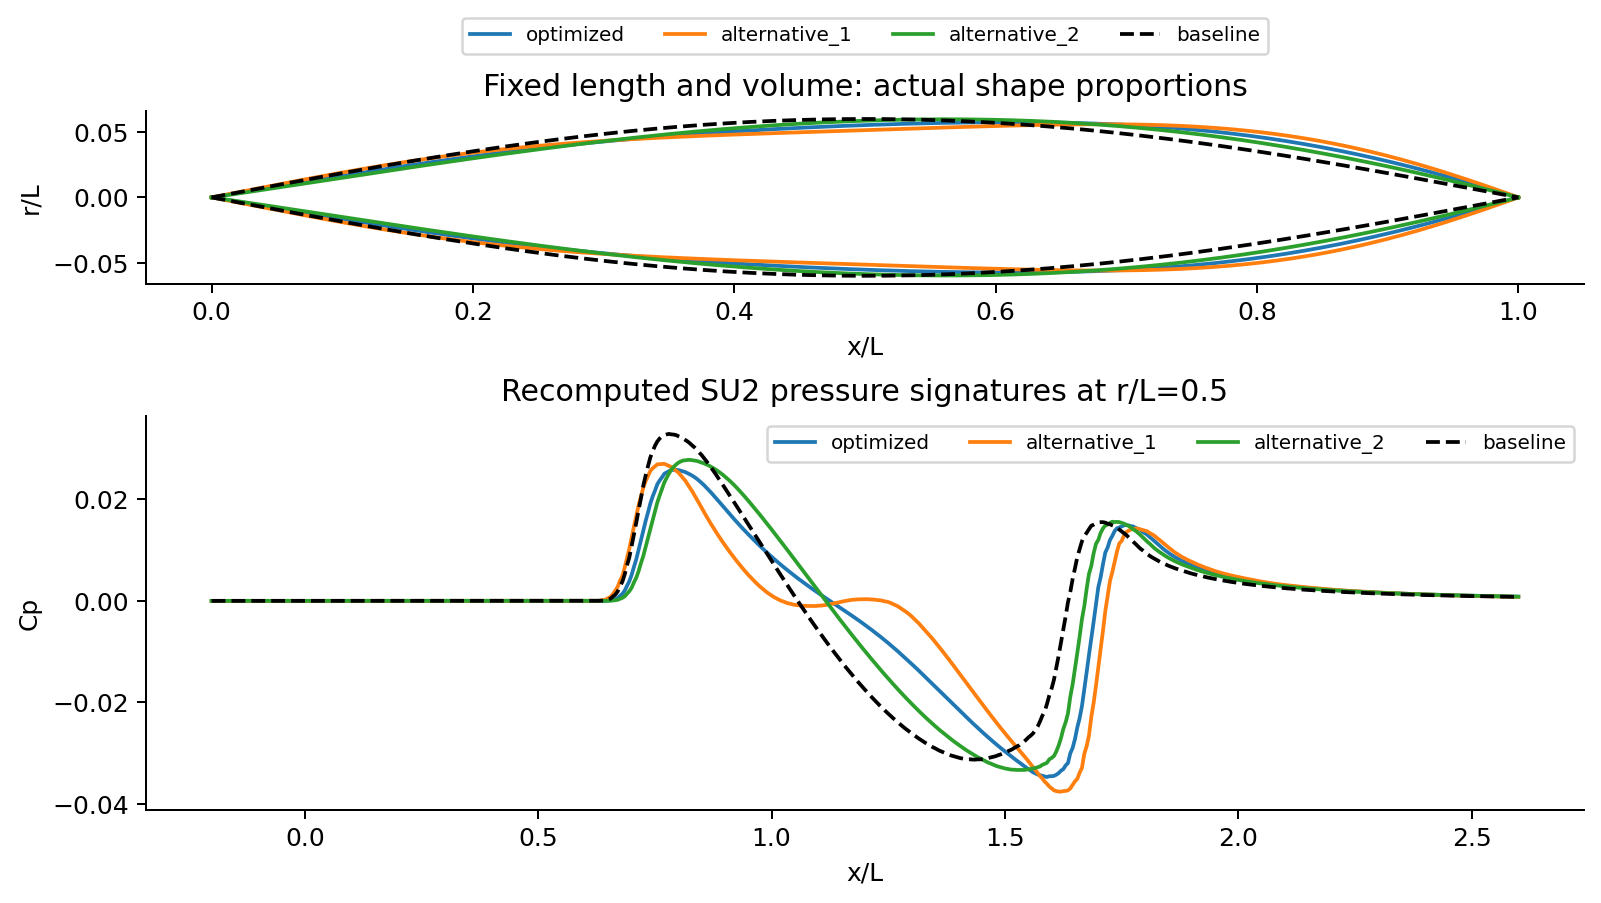

In [7]:
new_proposal=optimize(models[selected],write=False)
print('Reproduced surrogate optimum:',new_proposal['candidates'][0])
candidates=json.loads((E/'design_candidates.json').read_text())
print(candidates['objective'])
display(pd.DataFrame(candidates['candidates']))
print('Surrogate evaluations:',candidates['surrogate_evaluations'])
display(pd.read_csv(E/'design_comparison.csv'))
display(Image(filename=str(E/'design_shapes_signatures.png')))

## 6. Recompute and refine
The proposed shapes were meshed and solved again using SU2. The principal candidate was also evaluated on a finer mesh. Compare its achieved drag constraint and peak reduction at both resolutions. Similar peak objectives do not imply identical pressure waveforms or unique inverse geometries.

Fine mesh peak reduction [%]: 21.539112396536186
Finer mesh peak reduction [%]: 20.842171916355078


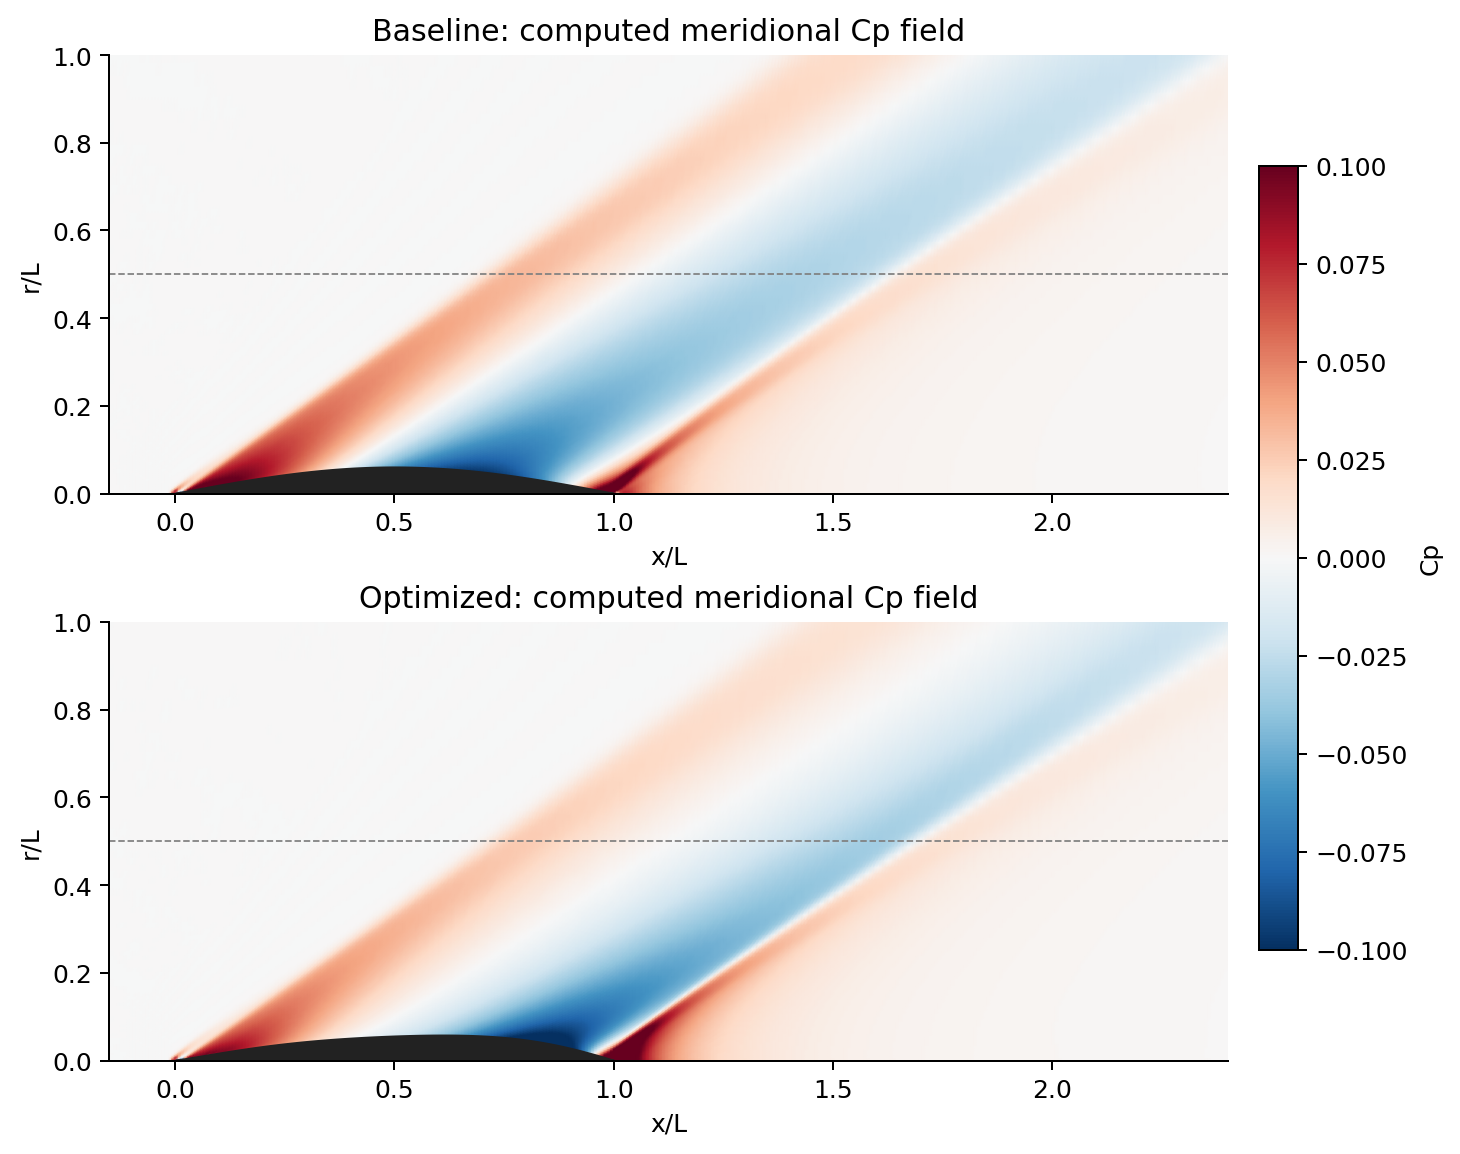

cone_pressure_within_3pct                     True
all_44_dataset_cases_converged                True
mesh_volume_within_0p2pct                     True
baseline_peak_mesh_within_5pct                True
baseline_drag_mesh_within_3pct                True
domain_peak_within_1pct                       True
optimized_peak_mesh_within_5pct               True
optimized_drag_mesh_within_3pct               True
design_recomputations_converged               True
optimized_drag_constraint_fine                True
optimized_drag_constraint_finer               True
peak_reduction_exceeds_5pct_both_meshes       True
selected_model_test_peak_error_below_10pct    True
Name: Scientific acceptance check, dtype: bool

In [8]:
display(Image(filename=str(E/'cfd_fields.png')))
checks=json.loads((E/'release_check.json').read_text())
display(pd.Series(checks['scientific_checks'],name='Scientific acceptance check'))
assert checks['scientific_pass']
print('Fine mesh peak reduction [%]:',100*summary['validation']['peak_reduction_fine'])
print('Finer mesh peak reduction [%]:',100*summary['validation']['peak_reduction_finer'])

## 7. Off-design checks
The Mach 1.7 and 1.9 cases are fresh CFD runs. The surrogate was trained only at Mach 1.8. Differences between extraction radii describe different observation locations; they do not quantify atmospheric uncertainty.

,peak_reduction,drag_change
1.7,0.213135,-0.048787
1.8,0.215391,-0.052827
1.9,0.214068,-0.057455


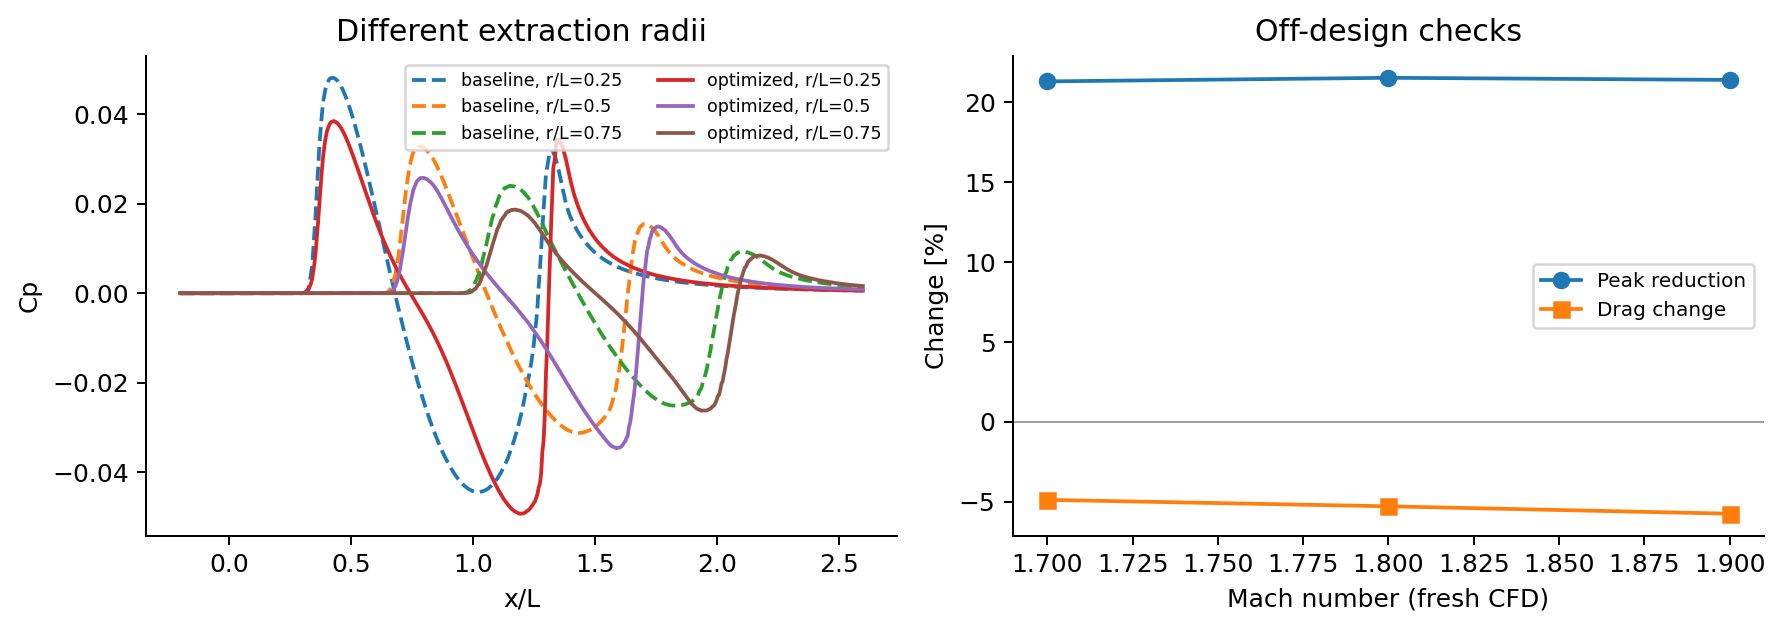

In [9]:
display(pd.DataFrame(summary['mach_stress_tests']).T)
display(Image(filename=str(E/'condition_checks.png')))

## 8. Optional: regenerate actual CFD
Install the pinned SU2 and Gmsh versions, set `SU2_CFD`, and follow `cases/week16_lowboom/README.md`. Regeneration commands are deliberately not launched by Run All because they replace retained data and may require substantial CPU time.

```bash
python qa/week16/benchmark.py
python qa/week16/campaign.py
python qa/week16/learning.py
python qa/week16/verify_designs.py
python qa/week16/report.py
```

For a new design, create a unique case name and use `cfd.py --a ... --b ... --level 1.5`, followed by `analyze.py CASE_NAME`. Check convergence and recompute on level 2 before accepting a claim.

## Reflection
1. Why is fixed volume necessary?
2. Which model gives the lowest validation error, and does it also have the lowest extrapolation error?
3. Does a small waveform L2 error guarantee a correct peak?
4. Did the proposed improvement survive grid refinement?
5. What additional equations and data are needed before claiming a quieter sonic boom on the ground?

**References:** Zheng et al. (2026), DOI 10.1016/j.ast.2026.113218; SU2 8.5.0 source and governing-equation documentation; Gmsh reference manual; Taylor and Maccoll (1933); NASA/AIAA Sonic Boom Prediction Workshops. Detailed links and the independently authored theory are in the lecture source.